# Correlation

In [4]:
# Correlation, Distribution Shapes, Hypothesis Basics

# Correlation - Pearson Vs Spearman

# df.corr()

Correlation measures whether two numeric columns tend to move together. Does one going up mean to other tends to go up too? (positive correlation)

or does one going up cause the other to go down? (Negative correlation) 

or no relationship at all (Zero correlation) 

Correlation is always a number between -1 and +1

 +1 = perfectly move together

 -1 = perfectly move opposite

 0 = no relationship at all

In [2]:
import os
os.chdir("Data Sets")

In [15]:
import pandas as pd

df = pd.read_csv("all_athlete_games.csv", low_memory=False)
noc_summary = df.groupby("NOC").agg(
    total_entries=("Entry ID","count"),
    total_medals=("Medal", lambda x: x.notna().sum()),
    gold_medals=("Medal", lambda x: (x=="Gold").sum()),
    avg_age=("Age","mean"),
    unique_sports=("Sport", lambda x: x.nunique())
).reset_index()
noc_summary = noc_summary[noc_summary["total_entries"] > 20]
print(len(noc_summary))

217


In [5]:
# Pearson Correlation - measures linear relationship

# syntax - df.corr(method = "pearson")  (this is the default method)

print(noc_summary[["total_entries","total_medals"]].corr(method="pearson"))

# A pearson correlation of 0.915 is a strong positive linear relationship between how many athletes a country sends and how many medals it wins.

# Pearson measures how tightly points cluster around a straight line.

               total_entries  total_medals
total_entries       1.000000      0.915031
total_medals        0.915031      1.000000


In [7]:
# Spearman correlation measures rank based on relationships

print(noc_summary[["total_entries","total_medals"]].corr(method="spearman"))

# Spearman converts every value to its rank first and measures whether the ranks move together .

# It doesnot care whether the relationship is perfectly straight line only whether it is consistently increasing.

               total_entries  total_medals
total_entries       1.000000      0.897692
total_medals        0.897692      1.000000


In [9]:
import pandas as pd
import numpy as np

x =  np.array([1,2,3,4,5,6,7,8,9,10])
y = 2**x
print(y)

print("Pearson:",pd.Series(x).corr(pd.Series(y),method="pearson"))

print("Spearman:",pd.Series(x).corr(pd.Series(y),method="spearman"))

[   2    4    8   16   32   64  128  256  512 1024]
Pearson: 0.7988372426181231
Spearman: 0.9999999999999999


In [12]:
%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


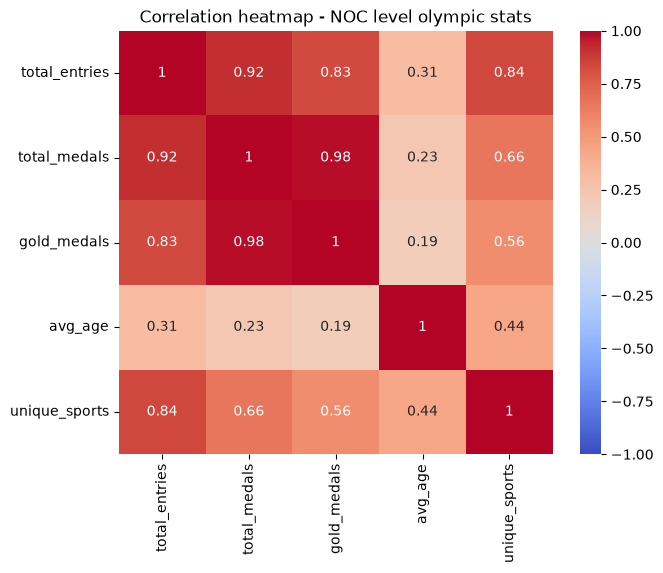

In [17]:
# df.corr() as a heatmap - seeing many relationships at once

# syntax - sns.heatmap[df.corr(),annot=True,cmap='coolwarm',vmin=-1,vmax=1]

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = noc_summary[["total_entries","total_medals","gold_medals","avg_age","unique_sports"]].corr()

plt.figure(figsize=(7,5.5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title("Correlation heatmap - NOC level olympic stats")
plt.show()

| Pair                          | Correlation | Interpretation                                        |
|------------------------------------|-----------------|----------------------------------------------------------------|
| total_entries vs total_medals            | 0.92                | Strong — more athletes sent, more medals won                       |
| total_medals vs gold_medals                 | 0.98                | Very strong — expected, gold medals are a SUBSET of total medals       |
| avg_age vs everything else                     | 0.19 – 0.44          | Weak — a country's typical athlete age has little to do with its medal count |
| total_entries vs unique_sports                    | 0.84                | Strong — countries competing in more entries also tend to compete across more sports |